# Machine Learning Algorithms
## Saad Ahmed Qadeer

---

**What we will cover today:**

1. Logistic Regression
2. Decision Trees
3. Random Forests
4. Support Vector Machines (SVM)
5. K-Nearest Neighbors (KNN)
6. Naive Bayes
7. K-Means Clustering (Unsupervised)
8. Gradient Boosting (XGBoost)

---

**A quick note before we begin:**

Machine learning is the practice of teaching computers to learn patterns from data, so they can make decisions or predictions without being explicitly programmed for every scenario. We feed the algorithm data, it finds patterns, and it generalizes those patterns to new, unseen data.

We will follow a consistent structure throughout:
- What the algorithm is and the core idea behind it
- When to use it
- How it works (intuition, not heavy math)
- Code implementation
- Evaluation

## Setup: Install and Import Libraries

Before anything, we import all the tools we need. Think of this as gathering your equipment before an experiment.

In [ ]:
# Core data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: the go-to ML library in Python
from sklearn.datasets import load_iris, load_breast_cancer, make_blobs, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# The algorithms we will teach
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans

# Suppress minor warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# Set a consistent plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("All libraries loaded successfully.")

---

## The Dataset We Will Use

We will use the **Iris dataset** for most classification tasks. It is a classic beginner dataset.

- 150 samples of iris flowers
- 4 features: sepal length, sepal width, petal length, petal width (all in cm)
- 3 classes: Setosa, Versicolor, Virginica

The goal: given measurements of a flower, predict its species.

For binary classification examples, we will use the **Breast Cancer dataset** (malignant vs benign).

In [ ]:
# Load the Iris dataset
iris = load_iris()
X_iris = iris.data        # Features (the measurements)
y_iris = iris.target      # Labels (the species: 0, 1, or 2)

# Put it in a DataFrame so it is easier to read
df_iris = pd.DataFrame(X_iris, columns=iris.feature_names)
df_iris['species'] = iris.target_names[y_iris]

print("Dataset shape:", df_iris.shape)
print("\nFirst 5 rows:")
df_iris.head()

In [ ]:
# Let's see how many samples we have per class
print("Class distribution:")
print(df_iris['species'].value_counts())

# Quick visualization of the data
sns.pairplot(df_iris, hue='species', diag_kind='kde')
plt.suptitle('Iris Dataset - Pairplot of All Features', y=1.02, fontsize=14)
plt.show()

# Reading the pairplot:
# - Each cell shows the relationship between two features
# - Diagonal cells show the distribution of a single feature
# - Colors represent different species
# - If clusters of colors separate well, the features are useful for classification

In [ ]:
# Split data into training and testing sets
# We train the model on 80% of the data and test it on the remaining 20%
# This simulates how the model will perform on NEW, unseen data
# validation dataset.....


X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris,
    test_size=0.2,      # 20% goes to testing
    random_state=42,    # Seed for reproducibility (so everyone gets same split)
    stratify=y_iris     # Ensures each class is equally represented in both sets
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

---

# 1. Logistic Regression

---

## What is it?

Despite the name, **Logistic Regression is a classification algorithm**, not a regression one. It predicts the **probability** that a data point belongs to a certain class.

## The Core Idea

Imagine you are trying to classify an email as spam or not spam. Logistic regression will look at features like the number of exclamation marks, certain keywords, etc., compute a weighted sum of those features, and then pass that sum through a special function called the **sigmoid function**.

The sigmoid function squishes any number into a value between 0 and 1. We interpret that value as a probability:
- Output close to 1: model is confident it belongs to class 1
- Output close to 0: model is confident it belongs to class 0
- Output around 0.5: model is unsure

We then set a threshold (usually 0.5) to make the final prediction.

## When to Use It

- Binary classification problems (yes/no, spam/not spam, disease/no disease)
- When you need probabilities, not just a class label
- As a strong baseline before trying complex models
- When interpretability matters (you can see which features influence the prediction)

## Key Parameter

**C** (regularization strength): Controls how strongly the model is penalized for being too complex. Lower C = more regularization = simpler model. Higher C = less regularization = model fits training data more closely (risk of overfitting).

In [ ]:
# Logistic Regression works best when features are on the same scale
# StandardScaler transforms features so each has mean=0, standard deviation=1
# This is called "feature scaling" or "normalization"

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Learn mean/std from training data, then scale
X_test_scaled  = scaler.transform(X_test)       # Use the SAME mean/std to scale test data

# IMPORTANT: Always fit the scaler only on training data.
# If you fit it on all data, you leak information about the test set into training.

# Create and train the model
log_reg = LogisticRegression(C=1.0, max_iter=200, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = log_reg.predict(X_test_scaled)

# Evaluate
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.2%}")

In [ ]:
# Confusion Matrix
# Rows = Actual class, Columns = Predicted class
# Diagonal = correct predictions, Off-diagonal = mistakes

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

# Classification Report
# Precision: Of all predictions for class X, how many were actually X?
# Recall:    Of all actual class X samples, how many did we correctly predict?
# F1-Score:  Harmonic mean of precision and recall (balance between the two)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=iris.target_names))

In [ ]:
# We can also look at the predicted PROBABILITIES (not just the final class)
# This is one of logistic regression's strong advantages

proba = log_reg.predict_proba(X_test_scaled[:5])  # Show first 5 test samples
prob_df = pd.DataFrame(proba, columns=iris.target_names)
prob_df['Predicted'] = iris.target_names[y_pred_lr[:5]]
prob_df['Actual'] = iris.target_names[y_test[:5]]

print("Predicted probabilities for first 5 test samples:")
prob_df

---

# 2. Decision Trees

---

## What is it?

A Decision Tree is a flowchart-like model that makes decisions by asking a series of questions about the features. It splits the data at each step using the question that best separates the classes.

## The Core Idea

Think of how you would describe a game of 20 questions. You ask: "Is the animal bigger than a dog?" If yes, go one way. If no, go another. Each question narrows down the possibilities until you reach a final answer.

A decision tree does the same thing automatically. At each node (question), it finds the feature and threshold that best separates the classes. It measures "best" using a metric called **Gini Impurity** (or Entropy). Lower impurity means the groups are purer (more of one class).

## When to Use It

- When you need the model to be explainable (you can literally draw the tree)
- When data has non-linear relationships
- Quick baseline with good performance
- When you do not want to normalize features (trees are scale-invariant)

## Key Parameters

- **max_depth**: How many levels deep the tree can go. Deeper = more complex = higher risk of overfitting.
- **min_samples_split**: Minimum samples needed to split a node.
- **criterion**: 'gini' or 'entropy' - the measure of impurity used to decide splits.

## Overfitting Warning

A decision tree that is allowed to grow without limits will memorize the training data perfectly but fail on new data. This is called **overfitting**. Controlling max_depth is the primary way to prevent it.

In [ ]:
# normilization, standardization, feature scaling,
# data as it is .....no transformation

In [ ]:
# Decision Trees do NOT require feature scaling
# We use the original (unscaled) data here

dt_model = DecisionTreeClassifier(
    max_depth=3,          # Limit depth to prevent overfitting
    criterion='gini',     # Use Gini Impurity to measure split quality
    random_state=42
)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {acc_dt:.2%}")

In [ ]:
# One of the greatest advantages of decision trees: we can VISUALIZE them
# Each node shows: the splitting question, gini value, number of samples, class distribution

plt.figure(figsize=(18, 8))
plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,          # Color nodes by their majority class
    rounded=True,
    fontsize=11
)
plt.title('Decision Tree Visualization (max_depth=3)', fontsize=16)
plt.show()

# How to read this tree:
# - Start at the root (top node)
# - Each node asks a yes/no question about one feature
# - True goes left, False goes right
# - Leaf nodes (no children) give the final prediction
# - The color intensity shows how confident the prediction is (darker = purer node)

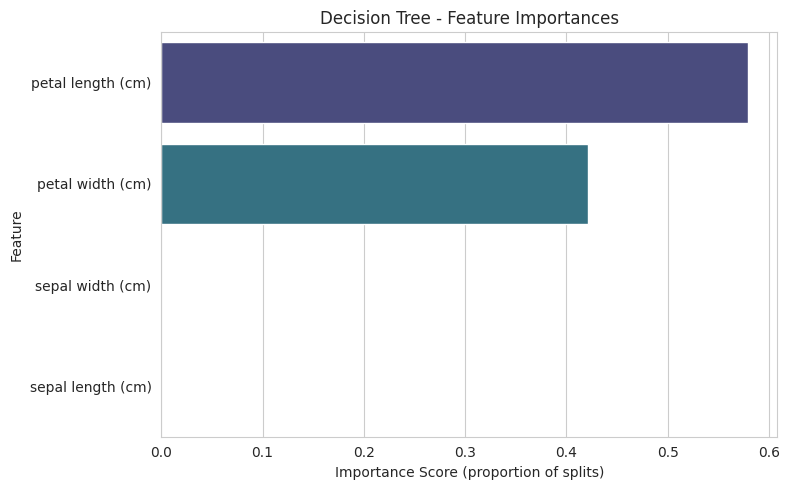

In [ ]:
# Feature Importance: Which features does the tree rely on the most?
importances = dt_model.feature_importances_
feat_df = pd.DataFrame({'Feature': iris.feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Decision Tree - Feature Importances')
plt.xlabel('Importance Score (proportion of splits)')
plt.tight_layout()
plt.show()

# A high importance means the tree relied heavily on that feature to make correct splits

In [ ]:
# Demonstrating Overfitting
# Let's compare a shallow tree vs a deep (unconstrained) tree

for depth in [2, 5, None]:  # None means no limit
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc  = accuracy_score(y_test,  tree.predict(X_test))
    depth_label = depth if depth else 'No limit'
    print(f"max_depth={depth_label:8} | Train Acc: {train_acc:.2%} | Test Acc: {test_acc:.2%}")

# Notice: with no depth limit, training accuracy = 100%, but test accuracy is lower
# The model memorized training data but did not generalize well
# This is the classic sign of OVERFITTING

max_depth=       2 | Train Acc: 96.67% | Test Acc: 93.33%
max_depth=       5 | Train Acc: 100.00% | Test Acc: 93.33%
max_depth=No limit | Train Acc: 100.00% | Test Acc: 93.33%


---

# 3. Random Forests

---

## What is it?

A Random Forest is an **ensemble** method that builds many decision trees and combines their predictions. The idea: a group of diverse, moderately good models together outperforms a single great model.

## The Core Idea

Think of it like polling a crowd. Instead of asking one expert (one decision tree), you ask 100 people with slightly different backgrounds and knowledge. Each one votes, and the majority vote wins. Even if some individuals make mistakes, the collective wisdom is usually correct.

Random Forest achieves diversity through two mechanisms:

1. **Bagging (Bootstrap Aggregating):** Each tree is trained on a different random sample of the training data (drawn with replacement). This means each tree sees a slightly different version of the dataset.

2. **Feature Randomness:** At each split, instead of considering ALL features, each tree randomly considers only a subset. This forces trees to be different from each other.

## Why is it Better Than a Single Tree?

A single decision tree has high variance - small changes in training data can produce a very different tree. By averaging many trees, the variance is reduced while bias stays low. This is the core of why ensemble methods work.

## When to Use It

- Strong default algorithm: often works well out of the box
- When overfitting is a concern with single decision trees
- When you have enough data to support multiple trees
- When you want feature importance estimates (more reliable than single tree)

## Key Parameters

- **n_estimators**: Number of trees in the forest. More trees = more stable, but slower. Usually 100-500 is a good range.
- **max_depth**: Max depth of each individual tree.
- **max_features**: How many features to consider at each split (default is the square root of total features).

In [ ]:
# Random Forests are also scale-invariant (no need to normalize)

rf_model = RandomForestClassifier(
    n_estimators=100,    # Build 100 trees
    max_depth=None,      # Let each tree grow as needed (forest averaging reduces overfitting)
    random_state=42,
    n_jobs=-1            # Use all available CPU cores for parallel training
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.2%}")
print(f"(Decision Tree was: {acc_dt:.2%})")

Random Forest Accuracy: 90.00%
(Decision Tree was: 96.67%)


SyntaxError: invalid syntax (784324716.py, line 1)

In [ ]:
# Feature Importances from Random Forest (averaged across all 100 trees)
# More reliable than a single tree's importances

rf_importances = rf_model.feature_importances_
rf_feat_df = pd.DataFrame({'Feature': iris.feature_names, 'Importance': rf_importances})
rf_feat_df = rf_feat_df.sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=rf_feat_df, palette='magma')
plt.title('Random Forest - Feature Importances (averaged over 100 trees)')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

In [ ]:
# Effect of number of trees on accuracy
# Demonstrates the "wisdom of crowds" principle

n_tree_range = [1, 5, 10, 20, 50, 100, 200]
test_accs = []

for n in n_tree_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    test_accs.append(accuracy_score(y_test, rf.predict(X_test)))

plt.plot(n_tree_range, test_accs, marker='o', color='forestgreen', linewidth=2)
plt.xlabel('Number of Trees')
plt.ylabel('Test Accuracy')
plt.title('Random Forest: Accuracy vs. Number of Trees')
plt.xticks(n_tree_range)
plt.ylim([0.8, 1.01])
plt.grid(True)
plt.show()

# Accuracy improves and stabilizes as we add more trees
# There is a point of diminishing returns - adding more trees after that adds compute but not accuracy

---

# 4. Support Vector Machines (SVM)

---

## What is it?

SVM is a powerful classification algorithm that finds the best boundary (called a **hyperplane**) to separate classes in the feature space. It is especially effective in high-dimensional spaces.

## The Core Idea

Imagine two groups of points on a 2D plane. Many lines could separate them. SVM finds the line that maximizes the **margin** - the distance between the line and the nearest points of each class. Those nearest points are called **support vectors**.

Why maximize the margin? Because a larger margin means the decision boundary is more confident and generalizes better to new data.

## The Kernel Trick

What if the data is not linearly separable? (i.e., no straight line can separate the classes.) SVM uses a mathematical technique called the **kernel trick** to project the data into a higher-dimensional space where it becomes linearly separable.

Common kernels:
- **Linear**: No transformation. Works when data is already linearly separable.
- **RBF (Radial Basis Function)**: The most popular. Handles circular and complex boundaries. Think of it as drawing circular regions around clusters.
- **Polynomial**: Uses polynomial features to create curved boundaries.

## When to Use It

- High-dimensional data (text classification, image classification)
- Cases where the number of features is larger than the number of samples
- When you want a very robust decision boundary

## Key Parameters

- **C** (Regularization): Low C = wider margin but may misclassify more training points. High C = narrower margin, tries to classify everything correctly (risk of overfitting).
- **kernel**: 'rbf', 'linear', 'poly', 'sigmoid'.
- **gamma**: (For RBF) Controls the influence of each training point. High gamma = each point has local influence. Low gamma = each point has broad influence.

In [ ]:
# SVM requires feature scaling - very important!
# The kernel computations are distance-based, so scale matters

svm_model = SVC(
    kernel='rbf',    # Radial Basis Function - handles non-linear boundaries
    C=1.0,           # Regularization parameter
    gamma='scale',   # 'scale' = 1 / (n_features * X.var()) - a sensible default
    probability=True # Needed if you want predict_proba() later
)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM (RBF kernel) Accuracy: {acc_svm:.2%}")

SVM (RBF kernel) Accuracy: 96.67%


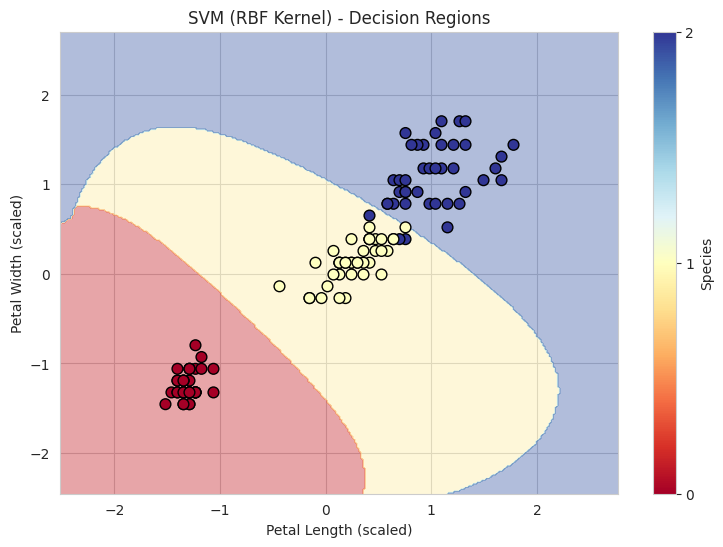

In [ ]:
# Visual demonstration of SVM decision boundaries
# We will use only 2 features to plot in 2D

X_2d = X_iris[:, 2:4]  # Use only petal length and petal width
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

scaler_2d = StandardScaler()
X_train_2d_s = scaler_2d.fit_transform(X_train_2d)
X_test_2d_s  = scaler_2d.transform(X_test_2d)

svm_2d = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_2d.fit(X_train_2d_s, y_train_2d)

# Create a mesh grid to plot decision regions
h = 0.02
x_min, x_max = X_train_2d_s[:, 0].min() - 1, X_train_2d_s[:, 0].max() + 1
y_min, y_max = X_train_2d_s[:, 1].min() - 1, X_train_2d_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

colors = ['#FFAAAA', '#AAFFAA', '#AAAAFF']
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
scatter = plt.scatter(X_train_2d_s[:, 0], X_train_2d_s[:, 1],
                      c=y_train_2d, cmap=plt.cm.RdYlBu, edgecolor='k', s=60)
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title('SVM (RBF Kernel) - Decision Regions')
plt.colorbar(scatter, ticks=[0,1,2], label='Species')
plt.show()

# The colored regions are the decision boundaries the SVM learned
# Points in each region will be classified as that class

---

# 5. K-Nearest Neighbors (KNN)

---

## What is it?

KNN is one of the most intuitive machine learning algorithms. It does not actually "learn" a model during training. Instead, it memorizes the entire training dataset and makes predictions by looking at the training examples that are closest to the new data point.

## The Core Idea

"Tell me who your neighbors are, and I will tell you who you are."

When a new data point arrives:
1. Find the K training examples that are closest to it (using a distance metric, usually Euclidean distance)
2. Let those K neighbors vote on the class
3. The majority class wins

Example: If K=5 and the 5 closest neighbors are [cat, cat, dog, cat, dog], the prediction is cat (3 votes vs 2).

## Choosing K

This is the most important decision in KNN:

- **K=1**: Very sensitive to noise. The model will perfectly fit training data (overfitting). If any single training point is mislabeled, it will cause wrong predictions nearby.
- **Large K**: Smoother decision boundaries but may underfit. You are averaging over too many points, including distant ones that may not be relevant.
- **Rule of thumb**: Start with K = sqrt(n) where n is the training size. Always try odd values to avoid ties.

## Lazy Learning

KNN is called a "lazy learner" because there is no training phase. All the work happens at prediction time. This makes training fast but prediction slow for large datasets.

## When to Use It

- Small to medium datasets
- When decision boundaries are complex and irregular
- As a strong baseline
- When training speed is important but prediction speed is less critical

## Important: Always Scale Features

KNN is entirely distance-based. If one feature has values in the thousands and another has values between 0 and 1, the first feature will dominate all distance calculations. Always scale your features first.

In [ ]:
# KNN with K=5
knn_model = KNeighborsClassifier(
    n_neighbors=5,       # Number of neighbors to vote
    metric='euclidean',  # Distance formula (straight-line distance)
    weights='uniform'    # All neighbors vote equally (alternative: 'distance' gives closer ones more weight)
)
knn_model.fit(X_train_scaled, y_train)  # Remember: KNN just memorizes data here

y_pred_knn = knn_model.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN (K=5) Accuracy: {acc_knn:.2%}")

KNN (K=5) Accuracy: 93.33%


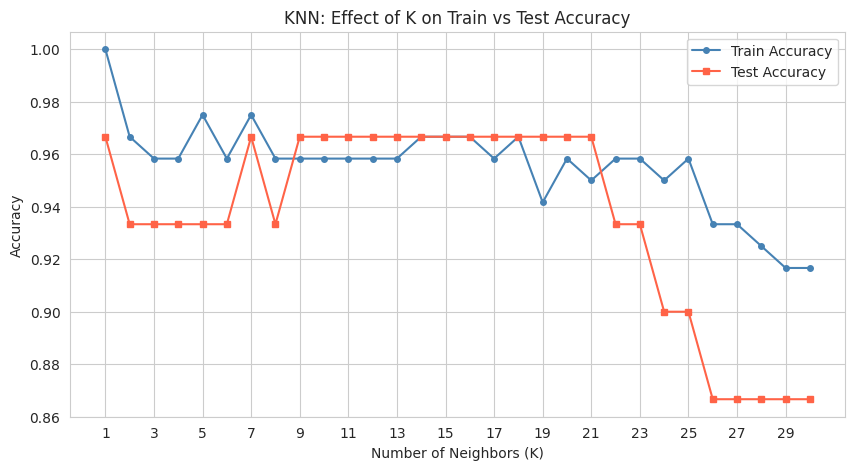

Best K based on test accuracy: 1


In [ ]:
# Finding the optimal K using a validation curve
# We will try different values of K and see which one performs best on test data

k_range = range(1, 31)
train_accs_knn = []
test_accs_knn  = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_accs_knn.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_accs_knn.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(k_range, train_accs_knn, label='Train Accuracy', color='steelblue', marker='o', markersize=4)
plt.plot(k_range, test_accs_knn,  label='Test Accuracy',  color='tomato',    marker='s', markersize=4)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN: Effect of K on Train vs Test Accuracy')
plt.legend()
plt.xticks(range(1, 31, 2))
plt.grid(True)
plt.show()

best_k = k_range.start + test_accs_knn.index(max(test_accs_knn))
print(f"Best K based on test accuracy: {best_k}")

# Notice:
# - K=1: Training accuracy is 100% (the model always correctly classifies training points)
#         but test accuracy is lower (overfitting)
# - As K increases, training accuracy drops but test accuracy may improve (less overfitting)
# - Very large K: underfitting (too many irrelevant neighbors included)

---

# 6. Naive Bayes

---

## What is it?

Naive Bayes is a probabilistic classifier based on **Bayes' Theorem**. It calculates the probability of each class given the observed features and predicts the class with the highest probability.

## The Core Idea

Bayes' Theorem says:

    P(Class | Features) = [P(Features | Class) * P(Class)] / P(Features)

In plain English: The probability that a data point belongs to a class, given its features, depends on how likely those features are in that class and how common that class is.

The "Naive" part: The algorithm assumes that all features are **independent** of each other. This is rarely true in practice (petal length and petal width of a flower are obviously correlated), but the algorithm still works surprisingly well despite this simplification.

**Gaussian Naive Bayes**: Assumes that the features for each class follow a Gaussian (normal) distribution. This is the variant we use for continuous features.

## When to Use It

- Text classification (spam filtering is the classic example - each word is a feature)
- When you have a large number of features
- When training speed is critical (Naive Bayes is extremely fast)
- When you have limited training data
- Real-time predictions

## When NOT to Use It

- When features are heavily correlated (the independence assumption is severely violated)
- When probability outputs need to be well-calibrated

## Key Advantage

Naive Bayes requires very little data to estimate parameters. Even with small datasets, it can produce reasonable results.

In [ ]:
# Gaussian Naive Bayes assumes features are normally distributed within each class
# It does not require feature scaling, but it does not hurt either

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)  # Training is just computing means and variances per class

y_pred_nb = nb_model.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {acc_nb:.2%}")

Naive Bayes Accuracy: 96.67%


In [ ]:
# What the model learned: means and variances of each feature per class
print("Class means (mean value of each feature per class):")
means_df = pd.DataFrame(
    nb_model.theta_,
    columns=iris.feature_names,
    index=iris.target_names
)
print(means_df.round(2))

print("\nClass variances (spread of each feature per class):")
vars_df = pd.DataFrame(
    nb_model.var_,
    columns=iris.feature_names,
    index=iris.target_names
)
print(vars_df.round(2))

# The model uses these statistics to calculate probabilities for new data points
# A new point is assigned to the class whose Gaussian distribution it best fits

Class means (mean value of each feature per class):
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                   4.99              3.41               1.48   
versicolor               5.93              2.75               4.25   
virginica                6.61              2.98               5.58   

            petal width (cm)  
setosa                  0.25  
versicolor              1.32  
virginica               2.04  

Class variances (spread of each feature per class):
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                   0.09              0.16               0.03   
versicolor               0.22              0.09               0.19   
virginica                0.46              0.12               0.32   

            petal width (cm)  
setosa                  0.01  
versicolor              0.03  
virginica               0.07  


In [ ]:
# Showing predicted probabilities from Naive Bayes
proba_nb = nb_model.predict_proba(X_test[:5])
proba_nb_df = pd.DataFrame(proba_nb, columns=iris.target_names)
proba_nb_df['Predicted'] = iris.target_names[y_pred_nb[:5]]
proba_nb_df['Actual'] = iris.target_names[y_test[:5]]

print("Naive Bayes predicted probabilities for first 5 test samples:")
proba_nb_df.round(3)

Naive Bayes predicted probabilities for first 5 test samples:


,setosa,versicolor,virginica,Predicted,Actual
0,1.0,0.000,0.000,setosa,setosa
1,0.0,0.088,0.912,virginica,virginica
2,0.0,1.000,0.000,versicolor,versicolor
3,0.0,1.000,0.000,versicolor,versicolor
4,1.0,0.000,0.000,setosa,setosa


---

# 7. K-Means Clustering

---

## What is it?

K-Means is an **unsupervised** learning algorithm. Unlike all the algorithms we have seen so far, it does not use labels. It tries to find structure in data on its own by grouping similar data points into **clusters**.

## The Core Idea

You tell the algorithm: "I think there are K groups in this data. Find them."

The algorithm works iteratively:

1. **Initialize**: Randomly place K centroids (cluster centers) in the feature space.
2. **Assign**: Assign each data point to the nearest centroid. That forms K clusters.
3. **Update**: Move each centroid to the mean (center of mass) of all points assigned to it.
4. **Repeat**: Steps 2 and 3 until the centroids stop moving (convergence).

The result: K clusters where each point belongs to the cluster with the nearest centroid.

## When to Use It

- Customer segmentation (grouping customers by purchasing behavior)
- Document clustering (grouping similar articles)
- Image compression (reducing colors by replacing similar ones with a centroid color)
- Anomaly detection (points far from any centroid are unusual)
- Exploratory analysis when you do not have labels

## Choosing K

The biggest challenge: you must choose K in advance. The **Elbow Method** helps:
- Run K-Means for different values of K
- For each K, compute the sum of squared distances from each point to its centroid (called **inertia**)
- Plot inertia vs K
- The "elbow" in the curve (where reduction in inertia slows down dramatically) suggests the optimal K

## Limitations

- Sensitive to the initial centroid placement (use multiple runs and take the best)
- Assumes clusters are roughly spherical and similar in size
- Does not handle clusters with complex shapes well

In [ ]:
# For K-Means, we pretend we do NOT have labels
# We will use all 150 samples (no train/test split needed for unsupervised learning)

scaler_km = StandardScaler()
X_scaled_all = scaler_km.fit_transform(X_iris)

# Apply K-Means with K=3 (since we know there are 3 species - but imagine we did not)
kmeans = KMeans(
    n_clusters=3,
    n_init=10,         # Run 10 times with different initializations, keep best result
    max_iter=300,      # Maximum iterations per run
    random_state=42
)
cluster_labels = kmeans.fit_predict(X_scaled_all)

print("Cluster assignments (first 15 samples):", cluster_labels[:15])
print("\nNumber of samples per cluster:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Cluster {c}: {n} samples")

Cluster assignments (first 15 samples): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Number of samples per cluster:
  Cluster 0: 53 samples
  Cluster 1: 50 samples
  Cluster 2: 47 samples


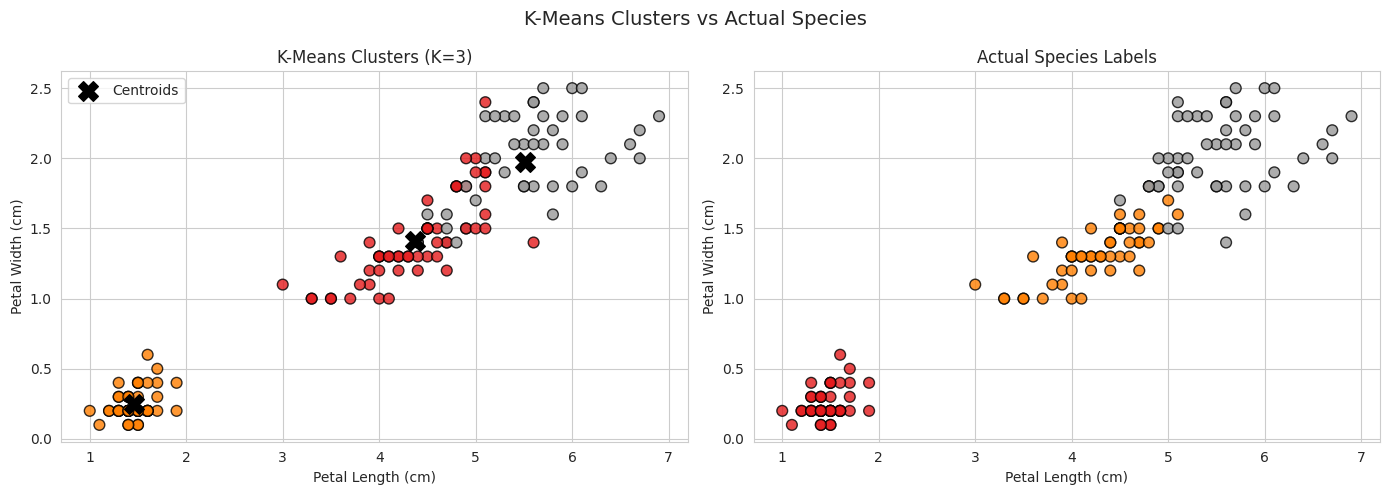

In [ ]:
# Visualizing clusters vs actual species
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# K-Means clusters (what the algorithm found)
scatter1 = ax1.scatter(X_iris[:, 2], X_iris[:, 3], c=cluster_labels,
                       cmap='Set1', s=60, edgecolor='k', alpha=0.8)
centers = scaler_km.inverse_transform(kmeans.cluster_centers_)
ax1.scatter(centers[:, 2], centers[:, 3], c='black', s=200, marker='X',
            label='Centroids', zorder=5)
ax1.set_xlabel('Petal Length (cm)')
ax1.set_ylabel('Petal Width (cm)')
ax1.set_title('K-Means Clusters (K=3)')
ax1.legend()

# Actual species (ground truth)
scatter2 = ax2.scatter(X_iris[:, 2], X_iris[:, 3], c=y_iris,
                       cmap='Set1', s=60, edgecolor='k', alpha=0.8)
ax2.set_xlabel('Petal Length (cm)')
ax2.set_ylabel('Petal Width (cm)')
ax2.set_title('Actual Species Labels')

plt.suptitle('K-Means Clusters vs Actual Species', fontsize=14)
plt.tight_layout()
plt.show()

# Compare the two plots: K-Means discovered groups that closely match the actual species
# This is remarkable - it found real structure without ever seeing the labels

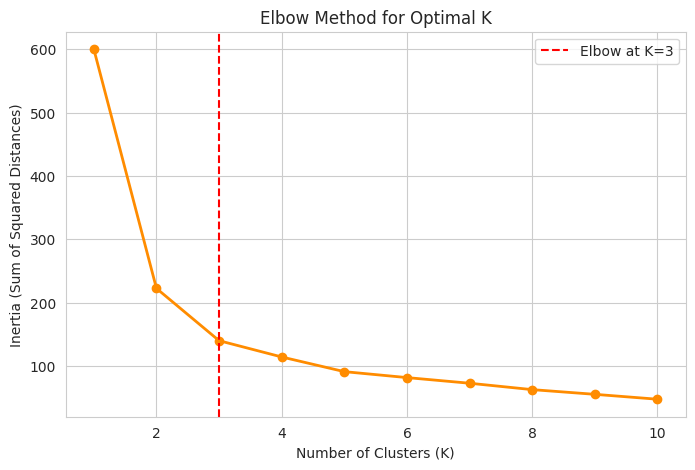

In [ ]:
# The Elbow Method - Finding the right K
# This is what you do when you do NOT know how many clusters to use

inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled_all)
    inertias.append(km.inertia_)  # Inertia = sum of squared distances to centroids

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', color='darkorange', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', label='Elbow at K=3')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal K')
plt.legend()
plt.grid(True)
plt.show()

# The curve bends sharply (the "elbow") at K=3
# After K=3, adding more clusters gives diminishing improvement
# This suggests K=3 is the natural grouping in the data

---

# 8. Gradient Boosting

---

## What is it?

Gradient Boosting is another ensemble method. Unlike Random Forest which builds trees in parallel (independently), Gradient Boosting builds trees **sequentially** - each new tree tries to correct the mistakes of the previous ones.

## The Core Idea

Imagine a student learning from mistakes. After the first exam, the teacher identifies which questions the student got wrong. The student then focuses specifically on those weak areas. After the second exam, they focus on whatever is still wrong. And so on.

Gradient Boosting does this mathematically:

1. Start with a simple initial prediction (e.g., the mean of all targets)
2. Calculate the **residuals** (errors): how wrong was the prediction for each sample?
3. Train a decision tree to predict those residuals (not the target directly)
4. Add that tree's predictions to the ensemble (with a small multiplier called the learning rate)
5. Recalculate residuals and repeat

Each tree is small (called a "weak learner" or "stub") but together they form a powerful model.

## Boosting vs Bagging

| Concept | Random Forest (Bagging) | Gradient Boosting |
|---|---|---|
| Tree building | Parallel (independent) | Sequential (each fixes previous errors) |
| Goal | Reduce variance | Reduce both variance and bias |
| Speed | Faster (parallel) | Slower |
| Overfitting risk | Lower | Higher (needs careful tuning) |

## When to Use It

- Tabular/structured data competitions (this is often the winning algorithm)
- When you want the best possible accuracy on structured data
- When you can afford longer training time and hyperparameter tuning

## Key Parameters

- **n_estimators**: Number of trees to build sequentially.
- **learning_rate**: How much each tree contributes. Lower = more trees needed, but more robust. Typical range: 0.01 to 0.3.
- **max_depth**: Depth of each individual tree. Typically shallow (3-5) for boosting.
- **subsample**: Fraction of training data used for each tree (adding randomness helps prevent overfitting).

In [ ]:
# Gradient Boosting Classifier from scikit-learn
# (XGBoost is a more optimized version - we will show that below)

gb_model = GradientBoostingClassifier(
    n_estimators=100,     # Number of boosting rounds
    learning_rate=0.1,    # Step size - how much each tree contributes
    max_depth=3,          # Shallow trees work best for boosting
    subsample=0.8,        # Each tree uses 80% of training data (adds randomness)
    random_state=42
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {acc_gb:.2%}")

Gradient Boosting Accuracy: 90.00%


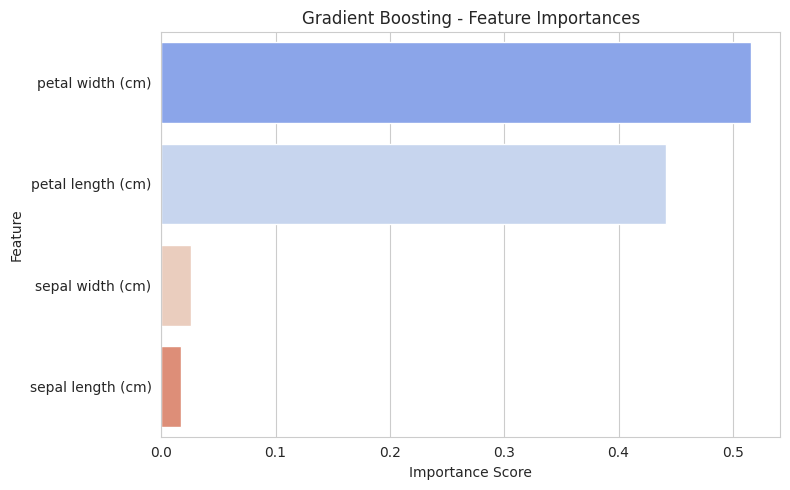

In [ ]:
# Feature Importances from Gradient Boosting
gb_importances = gb_model.feature_importances_
gb_feat_df = pd.DataFrame({'Feature': iris.feature_names, 'Importance': gb_importances})
gb_feat_df = gb_feat_df.sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=gb_feat_df, palette='coolwarm')
plt.title('Gradient Boosting - Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

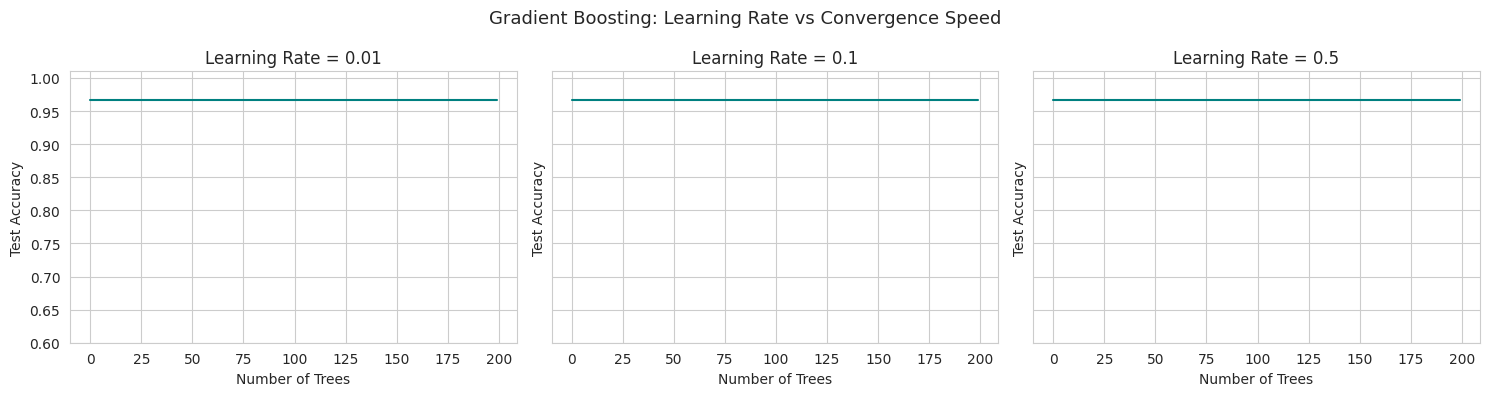

In [ ]:
# Effect of learning rate on training
# This shows the classic tradeoff: lower rate = slower but often better convergence

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, lr in zip(axes, [0.01, 0.1, 0.5]):
    gb = GradientBoostingClassifier(n_estimators=200, learning_rate=lr, max_depth=3, random_state=42)
    gb.fit(X_train, y_train)

    # Track test accuracy at each stage of boosting
    staged_acc = [accuracy_score(y_test, pred) for pred in gb.staged_predict(X_test)]

    ax.plot(staged_acc, color='teal', linewidth=1.5)
    ax.set_title(f'Learning Rate = {lr}')
    ax.set_xlabel('Number of Trees')
    ax.set_ylabel('Test Accuracy')
    ax.grid(True)
    ax.set_ylim([0.6, 1.01])

plt.suptitle('Gradient Boosting: Learning Rate vs Convergence Speed', fontsize=13)
plt.tight_layout()
plt.show()

# Low learning rate (0.01): converges slowly, needs more trees
# High learning rate (0.5): converges fast but may overshoot the best solution
# Middle ground (0.1): usually the best starting point

---

# Final Comparison: All Algorithms Side by Side

---

Now let us compare every algorithm we have covered in a single view.

Remember: accuracy alone does not tell the full story. The right algorithm depends on your data size, interpretability needs, training time budget, and whether features are correlated.

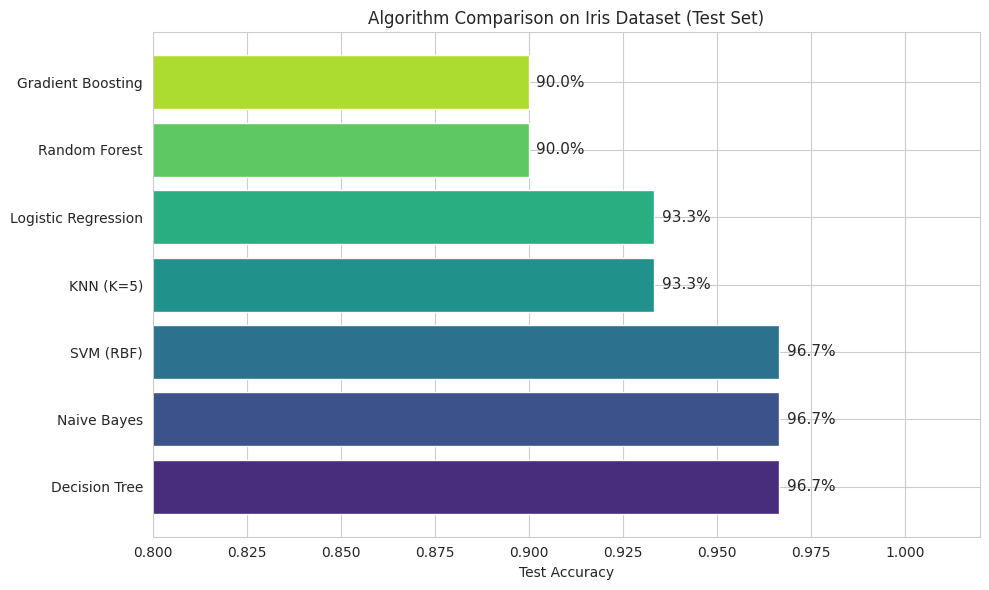

          Algorithm Test Accuracy %
      Decision Tree           96.7%
        Naive Bayes           96.7%
          SVM (RBF)           96.7%
          KNN (K=5)           93.3%
Logistic Regression           93.3%
      Random Forest           90.0%
  Gradient Boosting           90.0%


In [ ]:
# Consolidate all results
results = {
    'Logistic Regression':  acc_lr,
    'Decision Tree':        acc_dt,
    'Random Forest':        acc_rf,
    'SVM (RBF)':            acc_svm,
    'KNN (K=5)':            acc_knn,
    'Naive Bayes':          acc_nb,
    'Gradient Boosting':    acc_gb,
}

results_df = pd.DataFrame(list(results.items()), columns=['Algorithm', 'Test Accuracy'])
results_df = results_df.sort_values('Test Accuracy', ascending=False)
results_df['Test Accuracy %'] = (results_df['Test Accuracy'] * 100).round(1).astype(str) + '%'

# Plot comparison
plt.figure(figsize=(10, 6))
bars = plt.barh(
    results_df['Algorithm'],
    results_df['Test Accuracy'],
    color=sns.color_palette('viridis', len(results_df))
)
plt.xlabel('Test Accuracy')
plt.title('Algorithm Comparison on Iris Dataset (Test Set)')
plt.xlim(0.8, 1.02)

for bar, acc in zip(bars, results_df['Test Accuracy %']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             acc, va='center', fontsize=11)

plt.tight_layout()
plt.show()

print(results_df[['Algorithm', 'Test Accuracy %']].to_string(index=False))

---

## Algorithm Selection Guide

Use this as a reference when choosing an algorithm for a new problem.

| Algorithm | Best For | Needs Scaling? | Interpretable? | Handles Non-Linearity? |
|---|---|---|---|---|
| Logistic Regression | Binary classification baseline, probabilistic output | Yes | Yes | No |
| Decision Tree | Explainability, simple rules | No | Yes (visualizable) | Yes |
| Random Forest | General purpose, robust | No | Partial (feature importance) | Yes |
| SVM | High-dimensional data, text | Yes | No | Yes (with kernel) |
| KNN | Small datasets, irregular boundaries | Yes | Yes | Yes |
| Naive Bayes | Text, real-time, small data | No | Partial | No |
| K-Means | No labels, segmentation | Yes | Partial | No |
| Gradient Boosting | Best accuracy on tabular data | No | Partial (feature importance) | Yes |

---

## Key Concepts Summary

**Overfitting**: Model learns the training data too well, including its noise. Performs well on training data, poorly on new data. Fix with: regularization, limiting model complexity, more training data.

**Underfitting**: Model is too simple to capture the underlying patterns. Performs poorly on both training and test data. Fix with: more complex model, more features, less regularization.

**Bias-Variance Tradeoff**: Simple models have high bias (underfitting). Complex models have high variance (overfitting). Good ML is about finding the sweet spot.

**Supervised vs Unsupervised**:
- Supervised: You have labeled examples (features + correct answers). Goal: predict the label for new data.
- Unsupervised: No labels. Goal: find structure or groupings in the data on its own.

- Reinforcement Learning : You have an a

**Feature Scaling**: Bringing all features to a similar range. Required for distance-based algorithms (KNN, SVM, Logistic Regression). Not required for tree-based algorithms (Decision Tree, Random Forest, Gradient Boosting).

**Train/Test Split**: Always evaluate on data the model has never seen. This simulates real-world performance.